# INFO-6147-(01)-26W Deep Learning with Pytorch

## Project:

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**Description:**

## Setup Env

In [37]:
!pip install datasets
!pip install gradio
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 124.0 MB/s eta 0:00:00


## Import Libs

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
from torch.utils.data import random_split,Subset
from tqdm import tqdm
import streamlit as st
from groq import Groq
import io

## Check Device

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [24]:
EPOCHS=5
BATCH_SIZE = 128
LEARNING_RATE=0.001
DATA_PATH = './data'

## Load Dataset (Colab)

In [27]:
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.Food101(root=DATA_PATH, split='train', download=True, transform=transform)
test_dataset = datasets.Food101(root=DATA_PATH, split='test', download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"Load Food101 Successfully！Num of Classes: {num_classes}")

Load Food101 Successfully！Num of Classes: 101


## Build the model

In [38]:
# model = models.resnet50(pretrained=True)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,weight_decay=1e-4)

## Train the model

In [39]:
history={
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

for epoch in range(EPOCHS):
    # --- train process ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # training bar
    train_pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for i, (images, labels) in train_pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #calculate
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # update process bar
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100.*correct/total:.2f}%"})

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100. * correct / total

    # --- (Evaluate) ---
    model.eval()
    t_loss, t_correct, t_total = 0.0, 0, 0


    test_pbar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Test]", leave=False)

    with torch.no_grad():
        for images, labels in test_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            t_loss += loss.item()
            _, predicted = outputs.max(1)
            t_total += labels.size(0)
            t_correct += predicted.eq(labels).sum().item()

    epoch_test_loss = t_loss / len(test_loader)
    epoch_test_acc = 100. * t_correct / t_total

    # record to history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"==> Epoch {epoch+1} ends | Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

Epoch 1/5 [Train]: 100%|██████████| 592/592 [03:48<00:00,  2.59it/s, Loss=1.6528, Acc=47.89%]
                                                                   

==> Epoch 1 ends | Train Acc: 47.89% | Test Acc: 56.70%


Epoch 2/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.61it/s, Loss=1.0776, Acc=63.44%]
                                                                   

==> Epoch 2 ends | Train Acc: 63.44% | Test Acc: 57.02%


Epoch 3/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.61it/s, Loss=1.2636, Acc=70.41%]
                                                                   

==> Epoch 3 ends | Train Acc: 70.41% | Test Acc: 61.28%


Epoch 4/5 [Train]: 100%|██████████| 592/592 [03:47<00:00,  2.60it/s, Loss=0.8515, Acc=75.59%]
                                                                   

==> Epoch 4 ends | Train Acc: 75.59% | Test Acc: 64.25%


Epoch 5/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.62it/s, Loss=0.8034, Acc=79.79%]
                                                                   

==> Epoch 5 ends | Train Acc: 79.79% | Test Acc: 65.69%


## Graphing Loss Curve and Accuarcy Curve

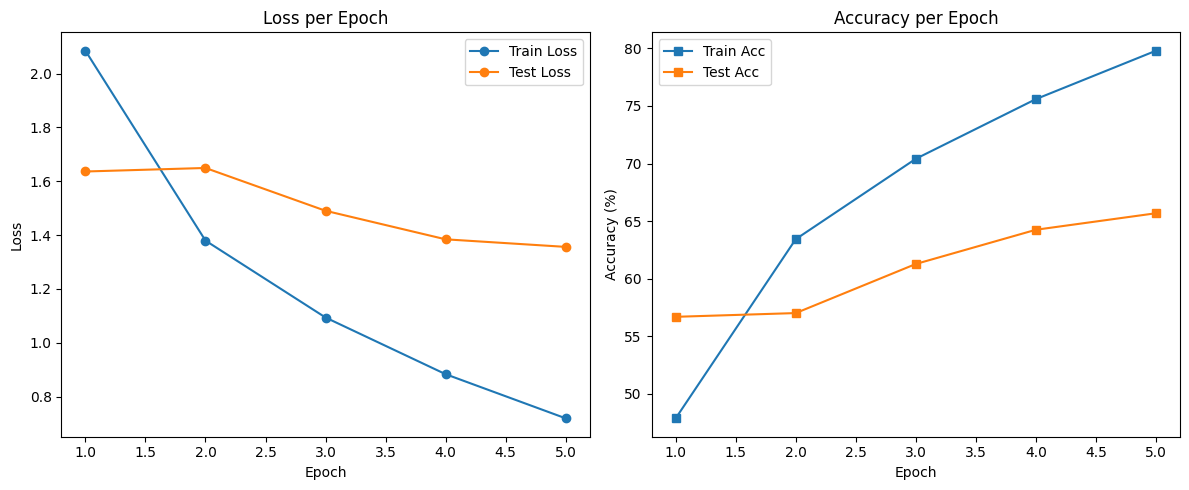

In [40]:
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), history['test_loss'], label='Test Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), history['train_acc'], label='Train Acc', marker='s')
plt.plot(range(1, EPOCHS+1), history['test_acc'], label='Test Acc', marker='s')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Visualize result

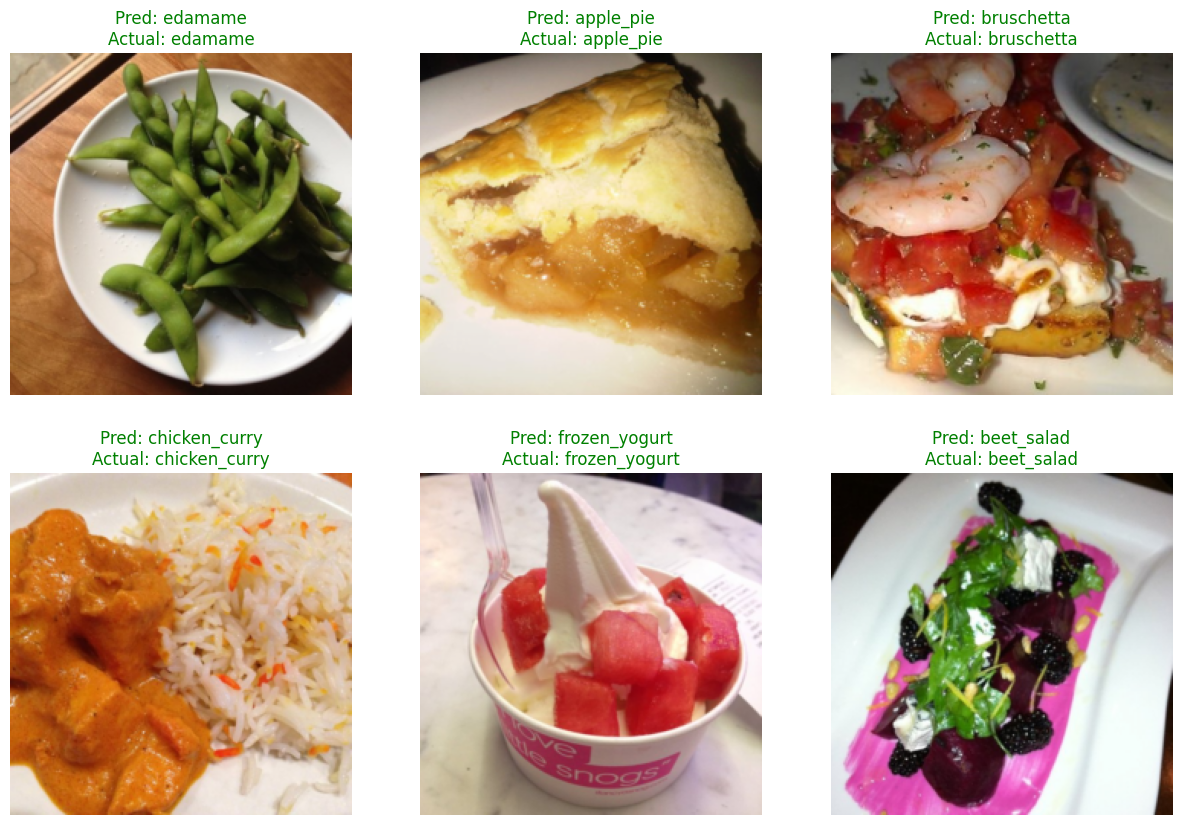

In [41]:
def visualize_results(model, dataset, num_images=6):
    model.eval()
    fig = plt.figure(figsize=(15, 10))
    class_names = dataset.classes

    # select randomly
    indices = np.random.choice(len(dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)

            output = model(input_tensor)
            _, pred = torch.max(output, 1)

            # transfer into showable picture
            img_display = image.permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_display = std * img_display + mean
            img_display = np.clip(img_display, 0, 1)

            ax = plt.subplot(2, 3, i + 1)
            color = 'green' if pred.item() == label else 'red'
            ax.set_title(f"Pred: {class_names[pred.item()]}\nActual: {class_names[label]}", color=color)
            plt.imshow(img_display)
            plt.axis('off')
    plt.show()

# visualize
visualize_results(model, test_dataset)

## Setup Enviroment for Llama

In [50]:
!pip install streamlit groq pyngrok
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 1s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [51]:
!curl ipv4.icanhazip.com

35.243.161.190


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

## API

In [48]:
from google.colab import userdata

# --- Get API key via Colab Secrets ---
try:

    api_key_from_colab = userdata.get("GROQ_API_KEY")
except:
    api_key_from_colab = None

## Create UI

In [49]:
%%writefile app.py
import streamlit as st
from groq import Groq

# --- 1. Basic Configuration ---
st.set_page_config(page_title="AI Food Guide", page_icon="🍣")

# Sidebar for API Key input to ensure privacy
with st.sidebar:
    st.title("🛠️ Settings")
    # set colab key as default, otherwise set api key as None
    api_key = st.text_input("Enter Groq API Key",
                            value=api_key_from_colab if api_key_from_colab else "",
                            type="password")
    if not api_key:
        st.info("Get your key at [console.groq.com](https://console.groq.com/)")


# --- 2. Llama Core Function ---
def ask_llama_chef(food_name, api_key):
    if not api_key:
        return "❌ Please enter your API Key in the sidebar!"

    try:
        client = Groq(api_key=api_key)
        prompt = f"""
        You are an expert Japanese travel guide serving a tourist from Canada.
        The vision model has identified this dish as "{food_name}".
        Please provide information in English: 1. Taste & Texture, 2. Travel Trivia, 3. Advice for Travelers.
        Tone: Humorous and friendly. Keep it under 150 words.
        """
        completion = client.chat.completions.create(
            model="llama3-8b-8192",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
        )
        return completion.choices[0].message.content
    except Exception as e:
        return f"Error occurred: {str(e)}"

# --- 3. UI Interface ---
st.title("🍣 AI Japanese Food Guide")
mock_predicted_label = st.selectbox(
    "Select a recognition result to test:",
    ["Sushi", "Ramen", "Takoyaki", "Tempura", "Okonomiyaki"]
)

if st.button("View Food Guide"):
    with st.spinner("Thinking..."):
        guide_text = ask_llama_chef(mock_predicted_label, api_key)
        st.chat_message("assistant", avatar="👨‍🍳").write(guide_text)

Writing app.py


# New Section